## Feature Selection

### EDA-driven reasoning for base features:

1. Price Features (Close, High, Low, Open) have very low correlation with y_return and are non-stationary — dropped as raw features.
2. Returnlag, log_return and OC_change are redundant (cross-correlation ~0.998 / 0.814). Kept as Ret_Lag1 for naming consistency.
3. HL_range and Volatility_5 overlap moderately (0.678) but each captures a different dimension (intraday vs rolling). Both defensible to keep.
4. Volume and Volume_log have near-zero correlation with y_return (~0.003). Dropped.
5. Price level can be made stationary and meaningful via ratio: (Close - MA_5) / MA_5 = Momentum_Deviation.
6. Ticker identity is relevant — label encoded with sorted mapping for reproducibility.

### Additional features from features engineering:
RSI, MACD_Norm, ATR_Pct, Ret_Lag2, BB_Pct, Price_vs_SMA50 are industry-standard stationary technical indicators that add signal not captured by the base set.
Rel_Volume and OC_Change are dropped — Rel_Volume shows weak signal, OC_Change is redundant with Ret_Lag1.

### Final feature set:
1. **Ret_Lag1** — 1-day lagged return (momentum)
2. **Ret_Lag2** — 2-day lagged return (extended momentum)
3. **RSI** — Relative Strength Index, momentum oscillator (0-100)
4. **MACD_Norm** — MACD normalized by price, trend momentum signal
5. **ATR_Pct** — Average True Range as % of price, normalized volatility
6. **HL_range** — Intraday High-Low range normalized by Close
7. **BB_Pct** — Bollinger Band %B, mean reversion signal
8. **Price_vs_SMA50** — Price relative to 50-day MA, trend strength
9. **Momentum_Deviation** — (Close - MA_5) / MA_5, short-term trend deviation
10. **Encoded_Ticker** — Label-encoded ticker identity

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/processed/sp500_panel.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Sort by Ticker + Date — critical for all groupby time-series operations
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print(f"Loaded: {len(df)} rows across {df['Ticker'].nunique()} tickers")
df.head()

Loaded: 1218220 rows across 501 tickers


,Date,Close,High,Low,Open,Volume,Ticker,y_return,y_direction,Returnlag,log_return,HL_range,OC_change,Volume_log,MA_5,Volatility_5
0,2015-12-28,38.539181,38.815913,38.299350,38.760566,1458200,A,0.013882,1,-0.008543,-0.008580,0.013404,-0.005712,14.192714,38.325180,0.009196
1,2015-12-29,39.074196,39.184887,38.668324,38.815916,1757000,A,-0.004485,0,0.013882,0.013787,0.013220,0.006654,14.379119,38.607442,0.010441
2,2015-12-30,38.898933,39.092647,38.751345,39.074198,834300,A,-0.005826,0,-0.004485,-0.004495,0.008774,-0.004485,13.634350,38.782706,0.009940
3,2015-12-31,38.672314,39.171786,38.589068,38.755560,1451000,A,-0.026788,0,-0.005826,-0.005843,0.015068,-0.002148,14.187764,38.811177,0.014453
4,2016-01-04,37.636372,38.098849,37.312639,37.978607,3287300,A,-0.003441,0,-0.026788,-0.027153,0.020890,-0.009011,15.005577,38.564199,0.014440


## Existing features from preprocessing
HL_range, Volatility_5, MA_5 already exist in the processed CSV.
We compute Momentum_Deviation from MA_5 here.

In [3]:
# Momentum_Deviation is fully computed in Cell 5 (feature engineering block).
# This standalone cell is kept for notebook structure but defers to Cell 5.
print("Momentum_Deviation will be computed in the main feature engineering cell.")


Momentum_Deviation will be computed in the main feature engineering cell.


## Additional feature engineering
Industry-standard stationary technical indicators added to enrich the feature pool.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
# Strategy: minimal, non-redundant, high-signal features only.
# Two new features: Vol_Price_Trend (volume-confirmed momentum) and
# Return_Dispersion (cross-sectional spread — market breadth, used in S1).
# ─────────────────────────────────────────────────────────────────────────────

# ── GROUP 1: MOMENTUM LAGS ─────────────────────────────────────────────────
df["Ret_Lag1"] = df.groupby("Ticker")["Close"].pct_change(1)
df["Ret_5d"]   = df.groupby("Ticker")["Close"].transform(lambda x: x.pct_change(5))

# ── GROUP 2: OSCILLATORS ──────────────────────────────────────────────────
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

df["RSI"] = df.groupby("Ticker")["Close"].transform(calculate_rsi)

# ── GROUP 3: VOLATILITY ───────────────────────────────────────────────────
def calculate_atr_pct(group):
    h, l, c = group["High"], group["Low"], group["Close"]
    tr  = pd.concat([(h - l), (h - c.shift()).abs(), (l - c.shift()).abs()], axis=1).max(axis=1)
    return tr.rolling(14).mean() / c

df["ATR_Pct"] = (df.groupby("Ticker")
                   .apply(calculate_atr_pct, include_groups=False)
                   .reset_index(level=0, drop=True))

def calculate_vol_ratio(group):
    h, l, c = group["High"], group["Low"], group["Close"]
    tr  = pd.concat([(h - l), (h - c.shift()).abs(), (l - c.shift()).abs()], axis=1).max(axis=1)
    atr = tr.rolling(14).mean()
    return atr / atr.rolling(20).mean().replace(0, np.nan)

df["Volatility_Ratio"] = (df.groupby("Ticker")
                            .apply(calculate_vol_ratio, include_groups=False)
                            .reset_index(level=0, drop=True))

# ── GROUP 4: TREND & MEAN REVERSION ──────────────────────────────────────
# Price vs SMA50 — medium-term trend anchor (2nd highest importance historically)
df["Price_vs_SMA50"] = df["Close"] / df.groupby("Ticker")["Close"].transform(
    lambda x: x.rolling(50).mean())

# Momentum Deviation — short-term: Close vs 5-day MA (horizon-aligned with label)
# Note: equivalent to Price_vs_SMA5 - 1, so no need for a separate SMA5 feature
df["Momentum_Deviation"] = (df["Close"] - df["MA_5"]) / df["MA_5"]

# Bollinger Band %B (20-period)
def calculate_bb_pct(series, length=20):
    mean = series.rolling(length).mean()
    std  = series.rolling(length).std()
    return (series - (mean - 2*std)) / (4 * std).replace(0, np.nan)

df["BB_Pct"] = df.groupby("Ticker")["Close"].transform(calculate_bb_pct)

# ── GROUP 5: VOLUME CONFIRMATION (NEW) ───────────────────────────────────
# Vol_Price_Trend = Ret_Lag1 × normalized volume
# Strong price moves on high volume = genuine signal vs noise
if 'Volume' in df.columns:
    vol_ma20 = df.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(20).mean())
    vol_norm = (df['Volume'] / vol_ma20.replace(0, np.nan)).clip(upper=5.0)
    df['Vol_Price_Trend'] = df['Ret_Lag1'] * vol_norm
    print("Vol_Price_Trend: computed from Volume column")
else:
    # Fallback: use normalized HL range as activity proxy (correlated with volume)
    hl = df['High'] - df['Low']
    hl_ma = df.groupby('Ticker')['High'].transform(lambda x: x.rolling(20).mean()) - \
            df.groupby('Ticker')['Low'].transform(lambda x: x.rolling(20).mean())
    hl_norm = (hl / hl_ma.replace(0, np.nan)).clip(upper=5.0)
    df['Vol_Price_Trend'] = df['Ret_Lag1'] * hl_norm
    print("Vol_Price_Trend: computed from HL-range proxy (Volume not found)")

# ── GROUP 6: CROSS-SECTIONAL MARKET BREADTH (NEW) ────────────────────────
# Return_Dispersion = std of Ret_5d across all tickers per date
# High dispersion → individual stock selection matters more
# Low dispersion  → everything moves together, regime dominates
# This is a DATE-LEVEL feature: same value for all tickers on a given day.
# Used as-is in Stage 1 (market-level). Merged back for Stage 2 context.
ret_disp = (df.groupby('Date')['Ret_5d']
              .std()
              .reset_index()
              .rename(columns={'Ret_5d': 'Return_Dispersion'}))
df = df.merge(ret_disp, on='Date', how='left')
print("Return_Dispersion: cross-sectional std of Ret_5d per date")

# ── TARGET: 5-DAY FORWARD RETURN ─────────────────────────────────────────
# 5-day horizon chosen because:
#   - Regime signal needs multiple days to express itself
#   - 1-day returns ~50% noise by construction
#   - Dir_x_Ret5 interaction is then horizon-aligned with the prediction target
df["y_return_5d"] = df.groupby("Ticker")["Close"].transform(lambda x: x.shift(-5) / x - 1)

# ── CLEANUP ───────────────────────────────────────────────────────────────
original_len = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nFeature Engineering Complete.")
print(f"Dropped {original_len - len(df):,} rows (rolling window NaNs + 5-day lookahead).")
print(f"Final dataset shape: {df.shape}")
print(f"Columns available: {list(df.columns)}")


Vol_Price_Trend: computed from Volume column
Return_Dispersion: cross-sectional std of Ret_5d per date

Feature Engineering Complete.
Dropped 27,610 rows (rolling window NaNs + 5-day lookahead).
Final dataset shape: (1190610, 27)
Columns available: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'y_return', 'y_direction', 'Returnlag', 'log_return', 'HL_range', 'OC_change', 'Volume_log', 'MA_5', 'Volatility_5', 'Ret_Lag1', 'Ret_5d', 'RSI', 'ATR_Pct', 'Volatility_Ratio', 'Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct', 'Vol_Price_Trend', 'Return_Dispersion', 'y_return_5d']


## Ticker Label Encoding
Sorted encoding ensures reproducibility — same ticker always maps to same integer regardless of load order.

In [5]:
# Sorted for reproducibility — unsorted .unique() order can vary by run
ticker_list = sorted(df["Ticker"].unique())
ticker_dict = {ticker: i for i, ticker in enumerate(ticker_list)}
df["Encoded_Ticker"] = df["Ticker"].map(ticker_dict)

print(f"Encoded {len(ticker_list)} tickers.")
df[["Ticker", "Encoded_Ticker"]].drop_duplicates().head(10)

Encoded 499 tickers.


,Ticker,Encoded_Ticker
0,A,0
2456,AAPL,1
4912,ABBV,2
7368,ABNB,3
8572,ABT,4
11028,ACGL,5
13484,ACN,6
15940,ADBE,7
18396,ADI,8
20852,ADM,9


## Final Feature Selection & Save

**16 model features across 5 groups:**

| Group | Features | Rationale |
|---|---|---|
| Momentum | Ret_Lag1, Ret_Lag2, Ret_Lag3, RSI, MACD_Norm, Price_Acceleration | Multi-lag returns + momentum curvature |
| Volatility | ATR_Pct, HL_range, Volatility_Ratio | Absolute vol + relative vol spike |
| Trend | Price_vs_SMA50, Price_vs_SMA20, Momentum_Deviation, BB_Pct, BB_Width | Short/medium/long-term trend + band expansion |
| Oscillators | Stochastic_K, CCI | Position within price range + mean-reversion |

**Regime interaction features** (computed in ModelTraining after regime_pred merge):
- `Regime_x_Ret1` = regime × Ret_Lag1 — amplifies directional return signal by regime state
- `Regime_x_Momentum` = regime × Momentum_Deviation — regime-conditional trend deviation
- `Regime_x_RSI` = regime × (RSI/100) — regime-conditional overbought/oversold

**Note:** `Encoded_Ticker` is kept as utility column for per-ticker `groupby` label computation only. It is NOT a model feature.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL FEATURE SET — 10 model features, minimal and non-redundant
#
# Dropped vs previous iteration:
#   HL_range         — r=0.70 with ATR_Pct (redundant volatility measure)
#   Ret_Lag2/Lag3    — near-zero importance in ablation study
#   Stochastic_K     — r=0.82 with RSI (fully redundant oscillator)
#   MACD_Norm        — low importance, slow signal for 5-day label
#   Price_Acceleration — low importance, noisy derivative
#   BB_Width         — captured by ATR_Pct and Volatility_Ratio
#   CCI              — redundant with RSI at 5-day horizon
#   Price_vs_SMA20   — sits between Momentum_Deviation(5d) and Price_vs_SMA50(50d),
#                       adds little additional signal
#
# Stage 1 uses: ATR_Pct, Volatility_Ratio, RSI, Ret_5d, Ret_Lag1, Return_Dispersion
# Stage 2 uses: 9 base + 4 regime interactions = 13 total
# ─────────────────────────────────────────────────────────────────────────────

FINAL_FEATURES = [
    "Date",
    "Encoded_Ticker",
    # Momentum
    "Ret_Lag1",           # 1-day return (immediate direction + Dir_x_Ret1 interaction)
    "Ret_5d",             # 5-day trend persistence (horizon-aligned with label)
    # Oscillator
    "RSI",                # momentum oscillator — Dir_x_RSI interaction partner
    # Volatility
    "ATR_Pct",            # absolute vol level — Vol_x_ATR interaction partner
    "Volatility_Ratio",   # relative vol spike (top importance historically)
    # Trend & mean reversion
    "Price_vs_SMA50",     # medium-term trend anchor (2nd highest importance)
    "Momentum_Deviation", # Close vs 5-day MA — short-term mean reversion
    "BB_Pct",             # Bollinger Band %B — band position
    # Volume confirmation (NEW)
    "Vol_Price_Trend",    # Ret_Lag1 × normalized volume — confirms signal strength
    # Market breadth (NEW, date-level)
    "Return_Dispersion",  # cross-sectional std of Ret_5d — used in Stage 1
    # Target
    "y_return_5d",
]

MODEL_FEATURES = [f for f in FINAL_FEATURES
                  if f not in ['Date', 'Encoded_Ticker', 'y_return_5d']]

ndf = df[FINAL_FEATURES].copy()
print(f"Final shape: {ndf.shape}")
print(f"Model features ({len(MODEL_FEATURES)}): {MODEL_FEATURES}")
ndf.head()


Final shape: (1190610, 13)
Model features (10): ['Ret_Lag1', 'Ret_5d', 'RSI', 'ATR_Pct', 'Volatility_Ratio', 'Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct', 'Vol_Price_Trend', 'Return_Dispersion']


,Date,Encoded_Ticker,Ret_Lag1,Ret_5d,RSI,ATR_Pct,Volatility_Ratio,Price_vs_SMA50,Momentum_Deviation,BB_Pct,Vol_Price_Trend,Return_Dispersion,y_return_5d
0,2016-03-09,0,0.001050,-0.023309,57.966095,0.020606,0.700861,1.003275,-0.018230,0.596292,0.000747,0.028922,0.022293
1,2016-03-10,0,-0.003934,-0.031122,54.655204,0.020951,0.720780,1.001271,-0.015909,0.541852,-0.002900,0.030846,0.034492
2,2016-03-11,0,0.032912,-0.002796,59.287856,0.021267,0.766153,1.035871,0.017059,0.845679,0.023718,0.028013,0.024471
3,2016-03-14,0,-0.005353,-0.010398,65.920810,0.020905,0.760928,1.031980,0.013770,0.771143,-0.002544,0.029118,0.016146
4,2016-03-15,0,-0.018708,0.005251,56.500849,0.021136,0.768187,1.014563,-0.006229,0.527829,-0.010635,0.029419,0.041525


In [7]:
import os
os.makedirs("data/features", exist_ok=True)
ndf.to_csv("data/features/sp500_panel_with_features.csv", index=False)
if os.path.exists("data/features/sp500_panel_with_features.csv"):
    print("SUCCESS: Feature set saved.")


SUCCESS: Feature set saved.


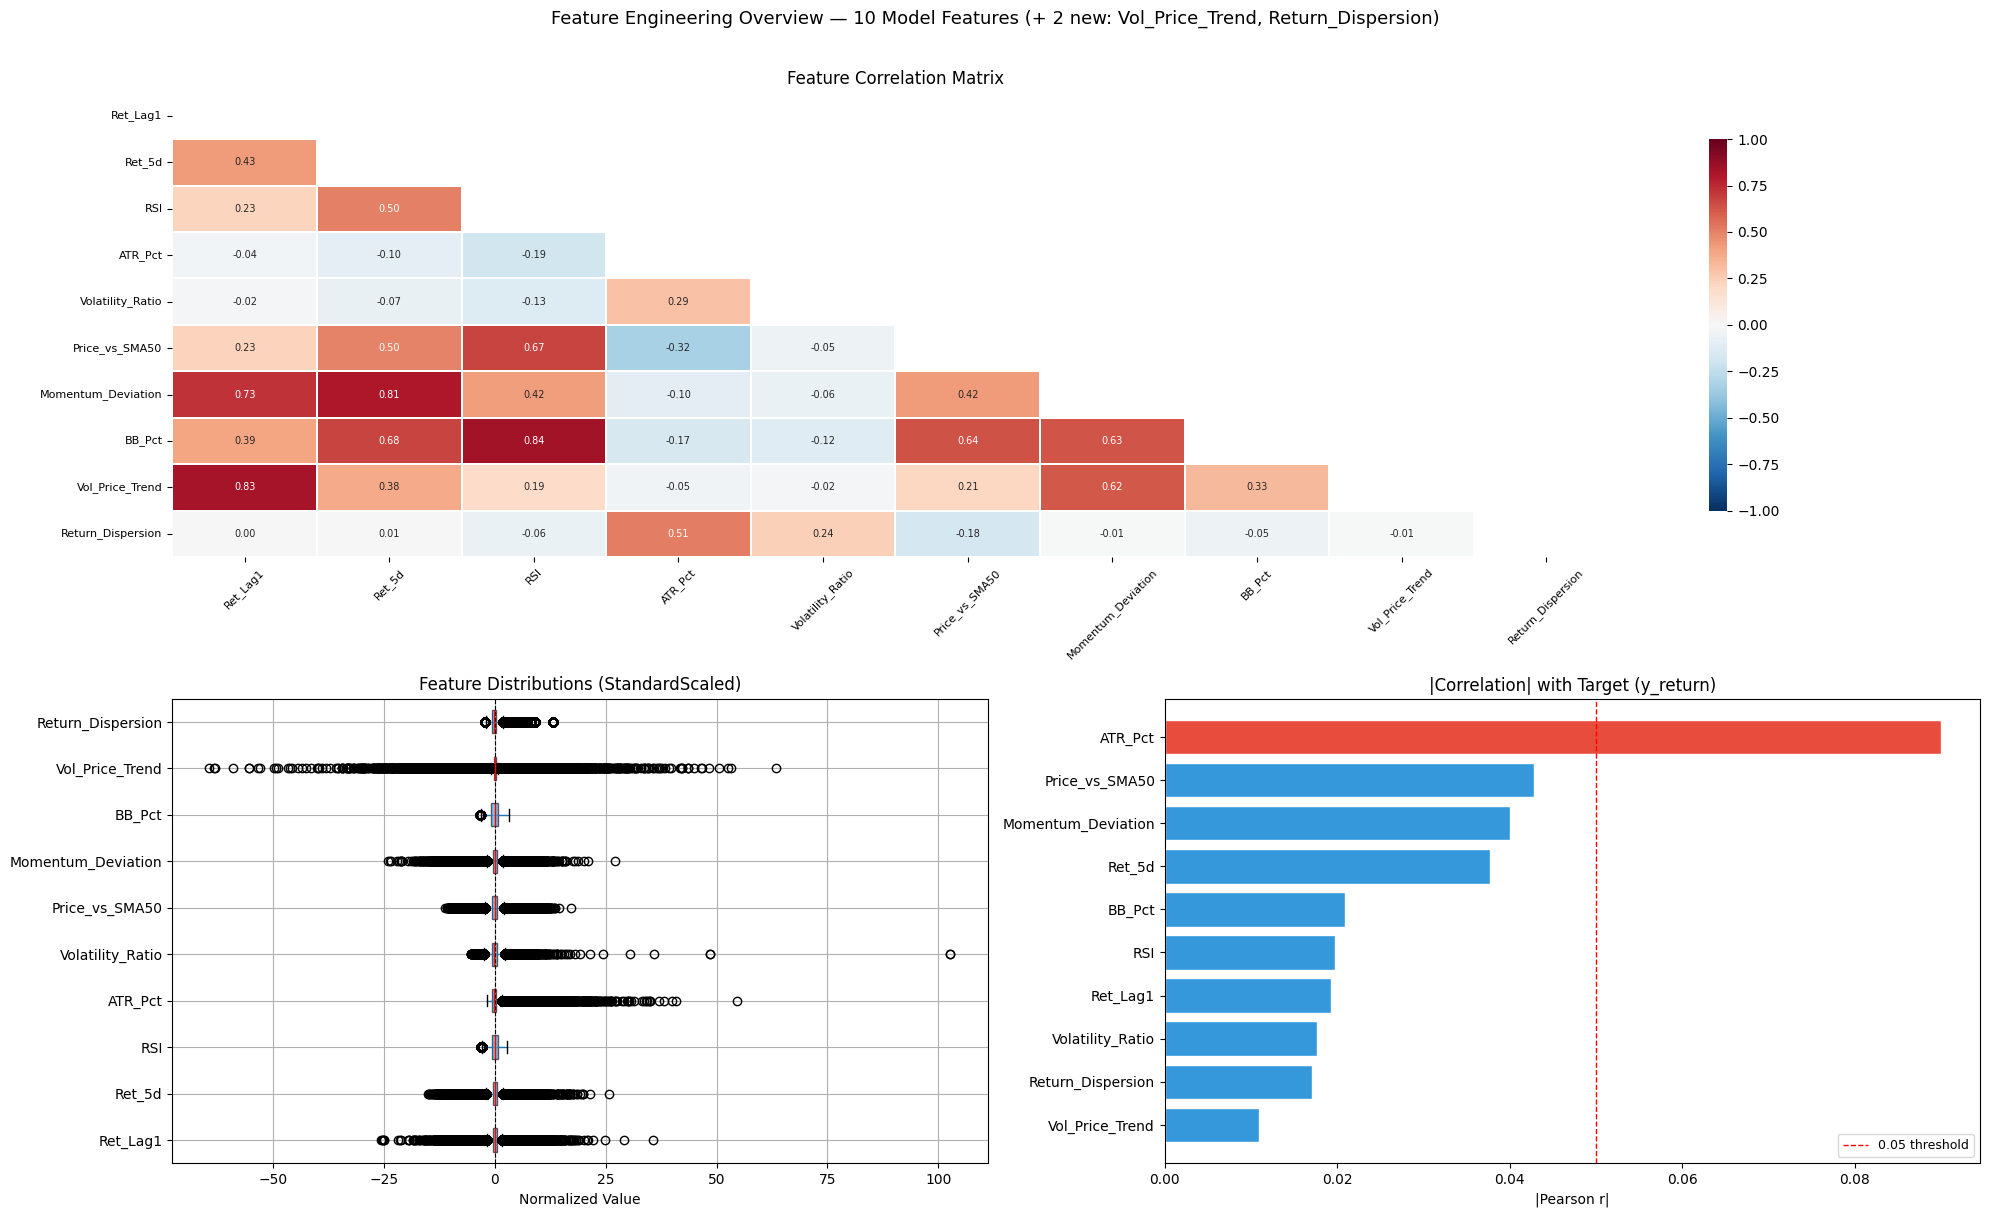

Feature engineering overview saved.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('plots', exist_ok=True)

# MODEL_FEATURES already defined in Cell 9

fig = plt.figure(figsize=(20, 12))
fig.suptitle('Feature Engineering Overview — 10 Model Features (+ 2 new: Vol_Price_Trend, Return_Dispersion)', fontsize=13, y=1.01)

# Top half: feature correlation heatmap
ax1 = fig.add_subplot(2, 2, (1, 2))
corr = ndf[MODEL_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.3, ax=ax1,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
ax1.set_title('Feature Correlation Matrix', fontsize=12)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', rotation=0,  labelsize=8)

# Bottom-left: feature distributions (boxplot normalized)
ax2 = fig.add_subplot(2, 2, 3)
# Normalize each feature for visual comparison
from sklearn.preprocessing import StandardScaler
sc    = StandardScaler()
normd = pd.DataFrame(sc.fit_transform(ndf[MODEL_FEATURES].dropna()),
                     columns=MODEL_FEATURES)
normd.boxplot(ax=ax2, vert=False, patch_artist=True,
              boxprops=dict(facecolor='#3498db', alpha=0.6),
              medianprops=dict(color='red'))
ax2.set_title('Feature Distributions (StandardScaled)', fontsize=12)
ax2.set_xlabel('Normalized Value')
ax2.axvline(0, color='black', lw=0.8, linestyle='--')

# Bottom-right: feature-target correlation (|corr| with y_return)
ax3 = fig.add_subplot(2, 2, 4)
target_corr = ndf[MODEL_FEATURES + ['y_return_5d']].corr()['y_return_5d'].drop('y_return_5d').abs().sort_values()
colors = ['#e74c3c' if v > 0.05 else '#3498db' for v in target_corr]
ax3.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax3.axvline(0.05, color='red', lw=1, linestyle='--', label='0.05 threshold')
ax3.set_title('|Correlation| with Target (y_return)', fontsize=12)
ax3.set_xlabel('|Pearson r|')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('plots/feature_engineering_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature engineering overview saved.")
